In [1]:
# from google.colab import files
# uploaded = files.upload()

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("PCOS_Dataset.csv")

In [3]:
df.columns = df.columns.str.strip()

In [4]:
print(df.shape)

(541, 43)


In [5]:
print(df.columns.tolist())

['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'LH_FSH_Ratio']


In [6]:
df.head()

,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),LH_FSH_Ratio
0,0,28,44.6,152.0,19.304017,15,78,22,10.48,2,...,1,0,110,80,3,3,18.0,18.0,8.5,0.462893
1,0,36,65.0,161.5,24.921163,15,74,20,11.70,2,...,0,0,120,70,3,5,15.0,14.0,3.7,0.161961
2,1,33,68.8,165.0,25.270891,11,72,18,11.80,2,...,1,0,120,80,13,15,18.0,20.0,10.0,0.158845
3,0,37,65.0,148.0,29.674945,13,72,20,12.00,2,...,0,0,120,70,2,2,15.0,14.0,7.5,0.292804
4,0,25,52.0,161.0,20.060954,11,72,18,10.00,2,...,0,0,120,80,3,4,16.0,14.0,7.0,0.226131


In [7]:
df = df.replace(["#NAME?", "", " "], np.nan)

In [8]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [9]:
df = df.fillna(df.median(numeric_only=True))

In [10]:
df.isnull().sum()

,0
PCOS (Y/N),0
Age (yrs),0
Weight (Kg),0
Height(Cm),0
BMI,0
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0
Hb(g/dl),0
Cycle(R/I),0


In [11]:
df["LH_FSH_Ratio"] = df["FSH/LH"]

In [12]:
basic_features = [
    "Age (yrs)",
    "BMI",
    "Cycle(R/I)",
    "Pimples(Y/N)",
    "hair growth(Y/N)",
    "Hair loss(Y/N)",
    "Weight gain(Y/N)",
    "Skin darkening (Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)",
    "PCOS (Y/N)"
]

df_basic = df[basic_features].copy()

In [13]:
advanced_features = [
    "Age (yrs)",
    "BMI",
    "Cycle(R/I)",
    "Pimples(Y/N)",
    "hair growth(Y/N)",
    "Hair loss(Y/N)",
    "Weight gain(Y/N)",
    "Skin darkening (Y/N)",
    "AMH(ng/mL)",
    "LH(mIU/mL)",
    "FSH(mIU/mL)",
    "LH_FSH_Ratio",
    "TSH (mIU/L)",
    "PRL(ng/mL)",
    "RBS(mg/dl)",
    "PCOS (Y/N)"
]

df_advanced = df[advanced_features].copy()

In [14]:
X_basic = df_basic.drop("PCOS (Y/N)", axis=1)
y_basic = df_basic["PCOS (Y/N)"]


In [15]:
X_adv = df_advanced.drop("PCOS (Y/N)", axis=1)
y_adv = df_advanced["PCOS (Y/N)"]

In [16]:
from sklearn.model_selection import train_test_split

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_basic, y_basic, test_size=0.2, random_state=42, stratify=y_basic
)

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_adv, y_adv, test_size=0.2, random_state=42, stratify=y_adv
)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler_basic = StandardScaler()
Xb_train_scaled = scaler_basic.fit_transform(Xb_train)
Xb_test_scaled = scaler_basic.transform(Xb_test)


In [19]:
scaler_adv = StandardScaler()
Xa_train_scaled = scaler_adv.fit_transform(Xa_train)
Xa_test_scaled = scaler_adv.transform(Xa_test)

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
lr_basic = LogisticRegression(max_iter=1000)
lr_basic.fit(Xb_train_scaled, yb_train)

yb_pred_lr = lr_basic.predict(Xb_test_scaled)
yb_prob_lr = lr_basic.predict_proba(Xb_test_scaled)[:,1]


In [22]:
lr_adv = LogisticRegression(max_iter=1000)
lr_adv.fit(Xa_train_scaled, ya_train)

ya_pred_lr = lr_adv.predict(Xa_test_scaled)
ya_prob_lr = lr_adv.predict_proba(Xa_test_scaled)[:,1]

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
rf_basic = RandomForestClassifier(n_estimators=200, random_state=42)
rf_basic.fit(Xb_train, yb_train)

yb_pred_rf = rf_basic.predict(Xb_test)
yb_prob_rf = rf_basic.predict_proba(Xb_test)[:,1]

In [25]:
rf_adv = RandomForestClassifier(n_estimators=200, random_state=42)
rf_adv.fit(Xa_train, ya_train)

ya_pred_rf = rf_adv.predict(Xa_test)
ya_prob_rf = rf_adv.predict_proba(Xa_test)[:,1]

In [26]:
from sklearn.svm import SVC

In [27]:
svm_basic = SVC(probability=True)
svm_basic.fit(Xb_train_scaled, yb_train)

yb_pred_svm = svm_basic.predict(Xb_test_scaled)
yb_prob_svm = svm_basic.predict_proba(Xb_test_scaled)[:,1]

In [28]:
svm_adv = SVC(probability=True)
svm_adv.fit(Xa_train_scaled, ya_train)

ya_pred_svm = svm_adv.predict(Xa_test_scaled)
ya_prob_svm = svm_adv.predict_proba(Xa_test_scaled)[:,1]

In [29]:
from sklearn.metrics import accuracy_score, roc_auc_score

In [30]:
print("===== BASIC MODEL =====")
print("LR:", accuracy_score(yb_test, yb_pred_lr), roc_auc_score(yb_test, yb_prob_lr))
print("RF:", accuracy_score(yb_test, yb_pred_rf), roc_auc_score(yb_test, yb_prob_rf))
print("SVM:", accuracy_score(yb_test, yb_pred_svm), roc_auc_score(yb_test, yb_prob_svm))


===== BASIC MODEL =====
LR: 0.8715596330275229 0.90220700152207
RF: 0.8348623853211009 0.870814307458143
SVM: 0.8440366972477065 0.8991628614916286


In [31]:
print("\n===== ADVANCED MODEL =====")
print("LR:", accuracy_score(ya_test, ya_pred_lr), roc_auc_score(ya_test, ya_prob_lr))
print("RF:", accuracy_score(ya_test, ya_pred_rf), roc_auc_score(ya_test, ya_prob_rf))
print("SVM:", accuracy_score(ya_test, ya_pred_svm), roc_auc_score(ya_test, ya_prob_svm))


===== ADVANCED MODEL =====
LR: 0.8440366972477065 0.8797564687975648
RF: 0.8348623853211009 0.8900304414003044
SVM: 0.8623853211009175 0.8858447488584476


In [32]:
import pandas as pd

In [33]:
results = pd.DataFrame({
    "Model": ["Basic-LR", "Basic-RF", "Basic-SVM", "Adv-LR", "Adv-RF", "Adv-SVM"],
    "Accuracy": [
        accuracy_score(yb_test, yb_pred_lr),
        accuracy_score(yb_test, yb_pred_rf),
        accuracy_score(yb_test, yb_pred_svm),
        accuracy_score(ya_test, ya_pred_lr),
        accuracy_score(ya_test, ya_pred_rf),
        accuracy_score(ya_test, ya_pred_svm)
    ],
    "ROC_AUC": [
        roc_auc_score(yb_test, yb_prob_lr),
        roc_auc_score(yb_test, yb_prob_rf),
        roc_auc_score(yb_test, yb_prob_svm),
        roc_auc_score(ya_test, ya_prob_lr),
        roc_auc_score(ya_test, ya_prob_rf),
        roc_auc_score(ya_test, ya_prob_svm)
    ]
})

results.sort_values(by="ROC_AUC", ascending=False)

,Model,Accuracy,ROC_AUC
0,Basic-LR,0.871560,0.902207
2,Basic-SVM,0.844037,0.899163
4,Adv-RF,0.834862,0.890030
5,Adv-SVM,0.862385,0.885845
3,Adv-LR,0.844037,0.879756
1,Basic-RF,0.834862,0.870814


In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

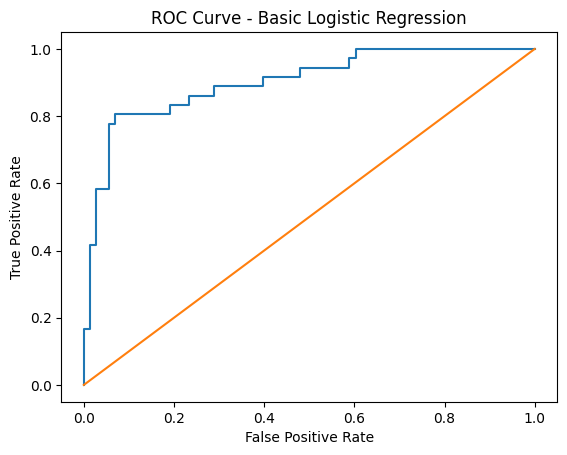

In [35]:
fpr, tpr, _ = roc_curve(yb_test, yb_prob_lr)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Basic Logistic Regression")
plt.show()

In [36]:
import pandas as pd

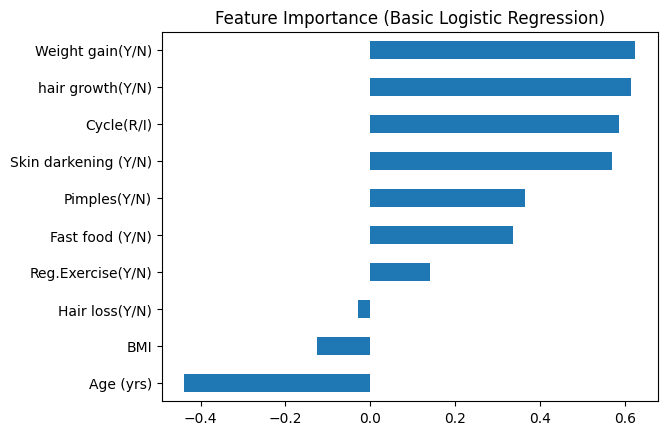

In [37]:
importance = pd.Series(lr_basic.coef_[0], index=X_basic.columns)
importance = importance.sort_values()

plt.figure()
importance.plot(kind='barh')
plt.title("Feature Importance (Basic Logistic Regression)")
plt.show()

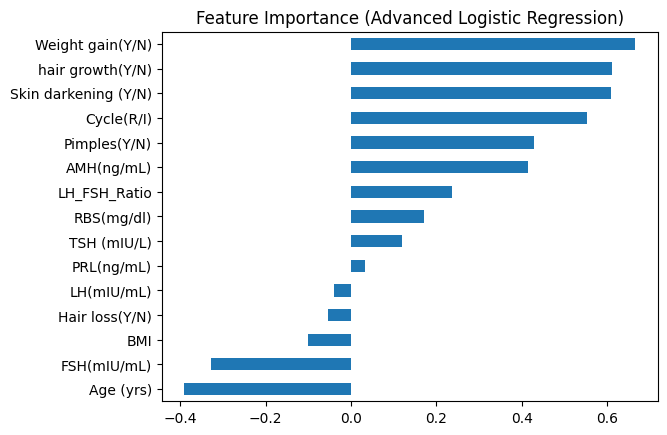

In [38]:
importance_adv = pd.Series(lr_adv.coef_[0], index=X_adv.columns)
importance_adv = importance_adv.sort_values()

plt.figure()
importance_adv.plot(kind='barh')
plt.title("Feature Importance (Advanced Logistic Regression)")
plt.show()

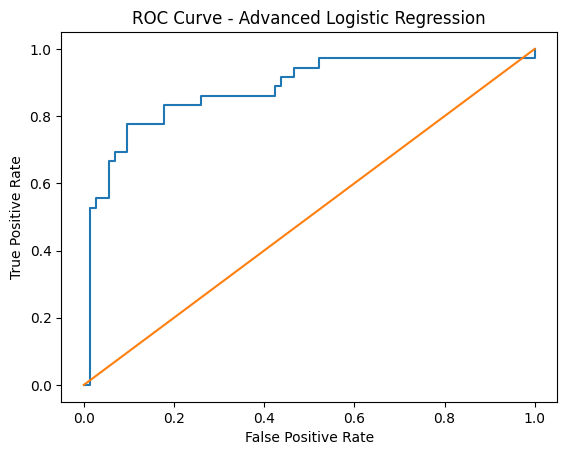

In [39]:
from sklearn.metrics import roc_curve

fpr_adv, tpr_adv, _ = roc_curve(ya_test, ya_prob_lr)

plt.figure()
plt.plot(fpr_adv, tpr_adv)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Advanced Logistic Regression")
plt.show()

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    "C": [0.1, 1, 10],
    "penalty": ["l2"]
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=5)
grid.fit(Xb_train_scaled, yb_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 0.1, 'penalty': 'l2'}


In [41]:
best_lr = grid.best_estimator_

yb_pred_best = best_lr.predict(Xb_test_scaled)
yb_prob_best = best_lr.predict_proba(Xb_test_scaled)[:,1]

print("Improved Accuracy:", accuracy_score(yb_test, yb_pred_best))
print("Improved ROC:", roc_auc_score(yb_test, yb_prob_best))

Improved Accuracy: 0.8715596330275229
Improved ROC: 0.9003044140030442


In [42]:
import numpy as np

new_user_basic = np.array([[
    25,
    28.5,
    1,
    1,
    1,
    0,
    1,
    1,
    1,
    0
]])

In [43]:
new_basic_scaled = scaler_basic.transform(new_user_basic)

pred_basic = lr_basic.predict(new_basic_scaled)
prob_basic = lr_basic.predict_proba(new_basic_scaled)[0][1]

if pred_basic[0] == 1:
    print(f" HIGH RISK (Basic Model): {prob_basic:.2f}")
else:
    print(f" LOW RISK (Basic Model): {prob_basic:.2f}")


 HIGH RISK (Basic Model): 0.83


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [44]:
new_user_adv = np.array([[
    25, 28.5, 1, 1, 1, 0, 1, 1, 5.2, 10.5, 6.0, 1.75, 2.5, 15.0, 110
]])

In [45]:
new_adv_scaled = scaler_adv.transform(new_user_adv)

pred_adv = svm_adv.predict(new_adv_scaled)
prob_adv = svm_adv.predict_proba(new_adv_scaled)[0][1]

if pred_adv[0] == 1:
    print(f" HIGH RISK (Advanced Model): {prob_adv:.2f}")
else:
    print(f" LOW RISK (Advanced Model): {prob_adv:.2f}")

 HIGH RISK (Advanced Model): 0.90


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [46]:
# ==============================
# ARTIFICIAL NEURAL NETWORK (ANN)
# ==============================

In [47]:
print(Xb_train_scaled.shape)
print(Xa_train_scaled.shape)

(432, 10)
(432, 15)


In [48]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

In [49]:
# BASIC
scaler_basic = StandardScaler()
Xb_train_scaled = scaler_basic.fit_transform(Xb_train)
Xb_test_scaled = scaler_basic.transform(Xb_test)

# ADVANCED
scaler_adv = StandardScaler()
Xa_train_scaled = scaler_adv.fit_transform(Xa_train)
Xa_test_scaled = scaler_adv.transform(Xa_test)

In [50]:
model_basic = keras.Sequential([
    keras.Input(shape=(Xb_train_scaled.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [51]:
model_basic.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [98]:
history_basic = model_basic.fit(
    Xb_train_scaled, yb_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9565 - loss: 0.1313 - val_accuracy: 0.7816 - val_loss: 0.6045
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9565 - loss: 0.1334 - val_accuracy: 0.7816 - val_loss: 0.6096
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9565 - loss: 0.1304 - val_accuracy: 0.7701 - val_loss: 0.6090
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9565 - loss: 0.1298 - val_accuracy: 0.7701 - val_loss: 0.6131
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9594 - loss: 0.1299 - val_accuracy: 0.7701 - val_loss: 0.6112
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9594 - loss: 0.1289 - val_accuracy: 0.7701 - val_loss: 0.6113
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9565 - loss: 0.1299 - val_accuracy: 0.7701 - val_loss: 0.6188
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9594 - loss: 0.1286 - val_accuracy: 0.7816 - val_loss:

In [99]:
loss_b, acc_b = model_basic.evaluate(Xb_test_scaled, yb_test)
print("Basic ANN Accuracy:", acc_b)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7982 - loss: 0.6421 
Basic ANN Accuracy: 0.7981651425361633


In [100]:
yb_prob = model_basic.predict(Xb_test_scaled)
yb_pred = (yb_prob > 0.5).astype(int)

print("Basic ANN ROC-AUC:", roc_auc_score(yb_test, yb_prob))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Basic ANN ROC-AUC: 0.8565449010654489


In [101]:
model_adv = keras.Sequential([
    keras.Input(shape=(Xa_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [102]:
model_adv.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [103]:
history_adv = model_adv.fit(
    Xa_train_scaled, ya_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5797 - loss: 0.6891 - val_accuracy: 0.6667 - val_loss: 0.6003
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7391 - loss: 0.5748 - val_accuracy: 0.8046 - val_loss: 0.5108
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8058 - loss: 0.5107 - val_accuracy: 0.8391 - val_loss: 0.4520
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8319 - loss: 0.4661 - val_accuracy: 0.8736 - val_loss: 0.4106
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8377 - loss: 0.4375 - val_accuracy: 0.8851 - val_loss: 0.3803
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8377 - loss: 0.4169 - val_accuracy: 0.8851 - val_loss: 0.3635
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8319 - loss: 0.4034 - val_accuracy: 0.8966 - val_loss: 0.3520
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8319 - loss: 0.3933 - val_accuracy: 0.9080 - val_loss

In [104]:
loss_a, acc_a = model_adv.evaluate(Xa_test_scaled, ya_test)
print("Advanced ANN Accuracy:", acc_a)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8073 - loss: 0.9091 
Advanced ANN Accuracy: 0.8073394298553467


In [105]:
ya_prob = model_adv.predict(Xa_test_scaled)
ya_pred = (ya_prob > 0.5).astype(int)

print("Advanced ANN ROC-AUC:", roc_auc_score(ya_test, ya_prob))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Advanced ANN ROC-AUC: 0.8751902587519027


In [106]:
# BASIC
new_basic_scaled = scaler_basic.transform(new_user_basic)
prob_basic = model_basic.predict(new_basic_scaled)[0][0]

print("Basic ANN Risk:", prob_basic)

# ADVANCED
new_adv_scaled = scaler_adv.transform(new_user_adv)
prob_adv = model_adv.predict(new_adv_scaled)[0][0]

print("Advanced ANN Risk:", prob_adv)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Basic ANN Risk: 0.5968639
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Advanced ANN Risk: 0.8472129


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [107]:
new_basic_df = pd.DataFrame(new_user_basic, columns=Xb_train.columns)

new_basic_scaled = scaler_basic.transform(new_basic_df)
prob_basic = model_basic.predict(new_basic_scaled)[0][0]

print("Basic ANN Risk:", prob_basic)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Basic ANN Risk: 0.5968639


In [108]:
new_adv_df = pd.DataFrame(new_user_adv, columns=Xa_train.columns)

new_adv_scaled = scaler_adv.transform(new_adv_df)
prob_adv = model_adv.predict(new_adv_scaled)[0][0]

print("Advanced ANN Risk:", prob_adv)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Advanced ANN Risk: 0.8472129


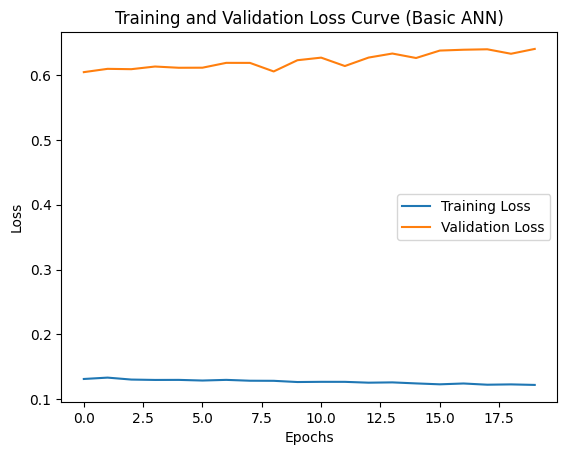

In [109]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history_basic.history['loss'])
plt.plot(history_basic.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve (Basic ANN)")
plt.legend(["Training Loss", "Validation Loss"])
plt.show()

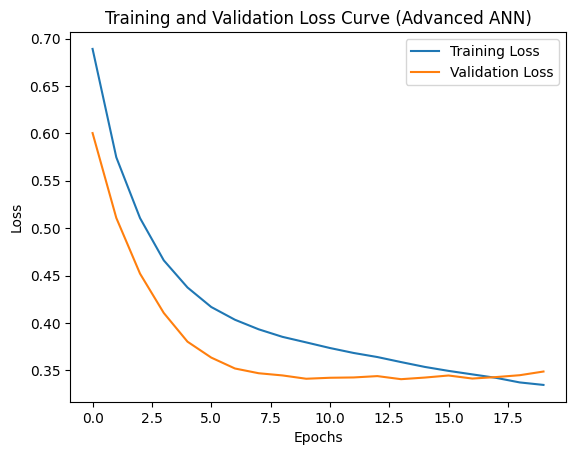

In [110]:
plt.figure()
plt.plot(history_adv.history['loss'])
plt.plot(history_adv.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Curve (Advanced ANN)")
plt.legend(["Training Loss", "Validation Loss"])
plt.show()

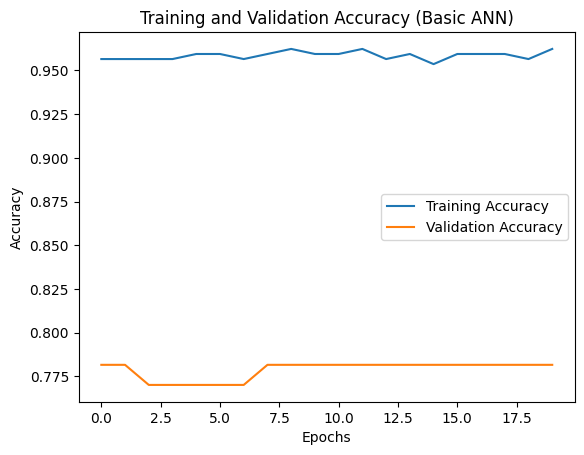

In [111]:
plt.figure()
plt.plot(history_basic.history['accuracy'])
plt.plot(history_basic.history['val_accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy (Basic ANN)")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.show()

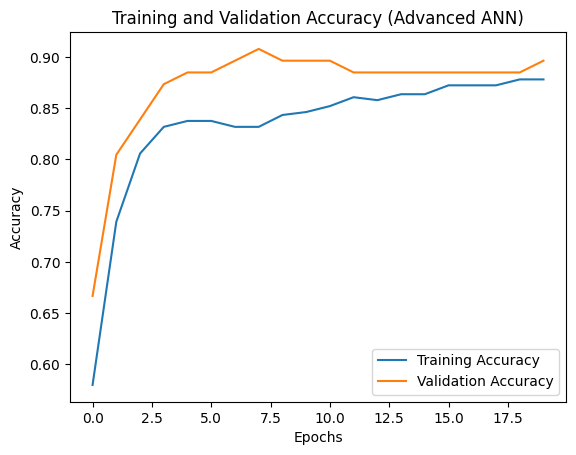

In [112]:
plt.figure()
plt.plot(history_adv.history['accuracy'])
plt.plot(history_adv.history['val_accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy (Advanced ANN)")
plt.legend(["Training Accuracy", "Validation Accuracy"])
plt.show()

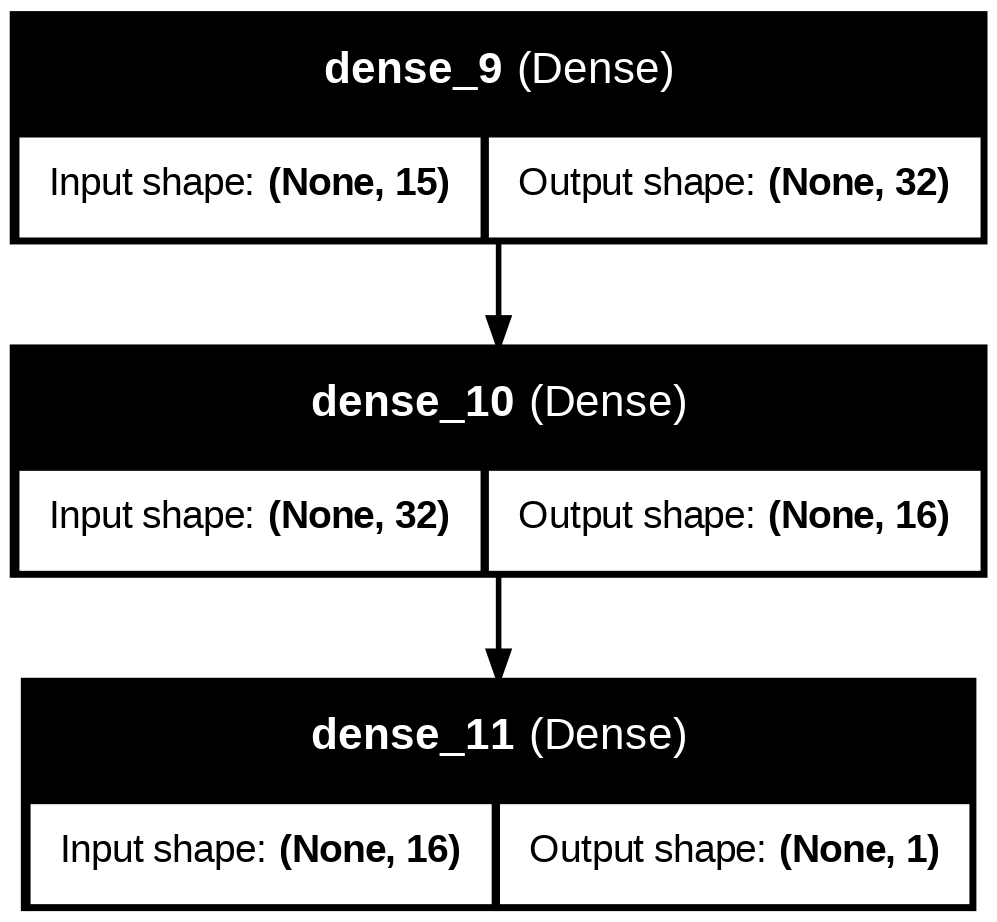

In [113]:
from tensorflow.keras.utils import plot_model

plot_model(model_adv, to_file='ann_advanced.png', show_shapes=True, show_layer_names=True)

In [114]:
results

,Model,Accuracy,ROC_AUC
0,Basic-LR,0.871560,0.902207
1,Basic-RF,0.834862,0.870814
2,Basic-SVM,0.844037,0.899163
3,Adv-LR,0.844037,0.879756
4,Adv-RF,0.834862,0.890030
5,Adv-SVM,0.862385,0.885845


In [115]:
from sklearn.metrics import roc_auc_score

roc_basic = roc_auc_score(yb_test, yb_prob)
print("Basic ANN ROC-AUC:", roc_basic)

Basic ANN ROC-AUC: 0.8565449010654489


In [116]:
roc_adv = roc_auc_score(ya_test, ya_prob)
print("Advanced ANN ROC-AUC:", roc_adv)

Advanced ANN ROC-AUC: 0.8751902587519027


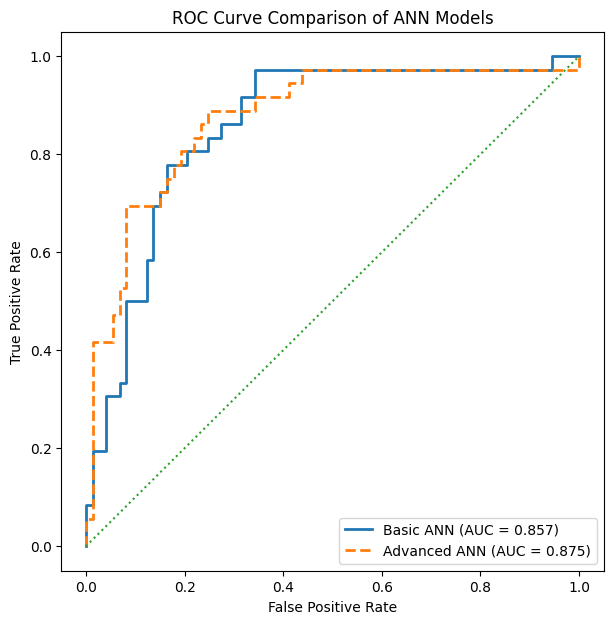

In [117]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC values for Basic ANN
fpr_basic, tpr_basic, _ = roc_curve(yb_test, yb_prob)

# ROC values for Advanced ANN
fpr_adv, tpr_adv, _ = roc_curve(ya_test, ya_prob)

# AUC values
roc_auc_basic = auc(fpr_basic, tpr_basic)
roc_auc_adv = auc(fpr_adv, tpr_adv)

# Plot
plt.figure(figsize=(7,7))

# Basic ANN ROC
plt.plot(
    fpr_basic,
    tpr_basic,
    linewidth=2,
    label=f'Basic ANN (AUC = {roc_auc_basic:.3f})'
)

# Advanced ANN ROC
plt.plot(
    fpr_adv,
    tpr_adv,
    linewidth=2,
    linestyle='--',
    label=f'Advanced ANN (AUC = {roc_auc_adv:.3f})'
)

# Random line
plt.plot([0,1], [0,1], linestyle=':')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Title
plt.title("ROC Curve Comparison of ANN Models")

# Legend
plt.legend(loc='lower right')

plt.show()

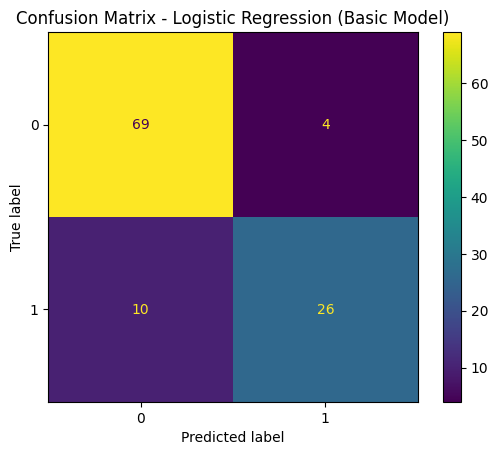

Confusion Matrix:
 [[69  4]
 [10 26]]


In [118]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(yb_test, yb_pred_lr)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression (Basic Model)")
plt.show()

# Print values
print("Confusion Matrix:\n", cm)

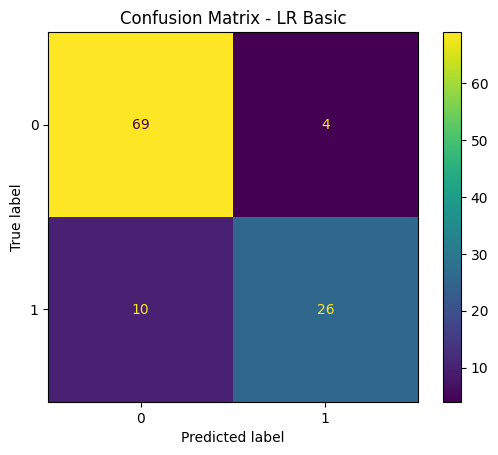

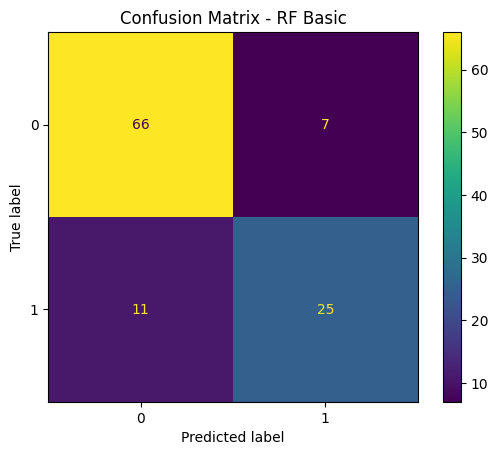

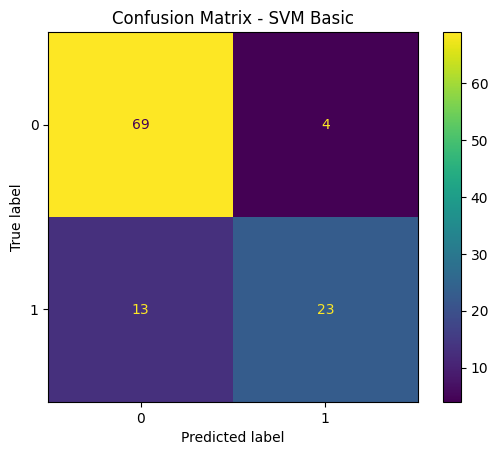

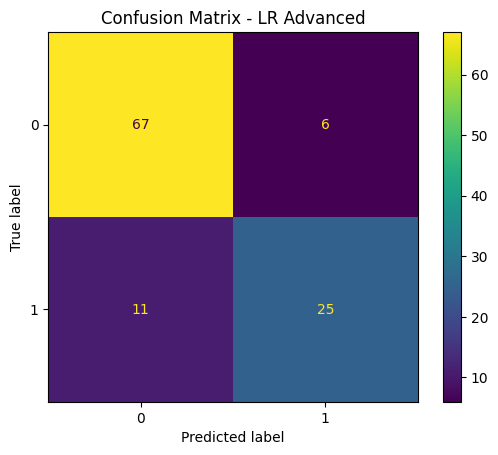

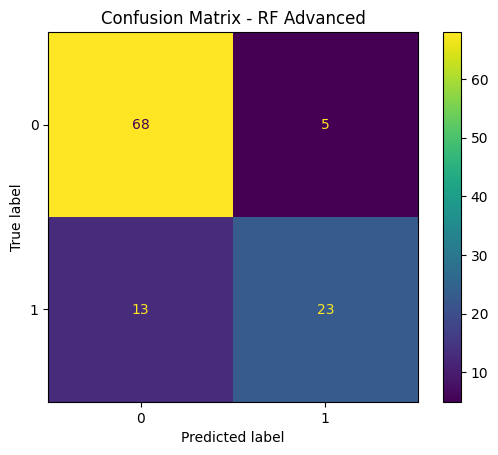

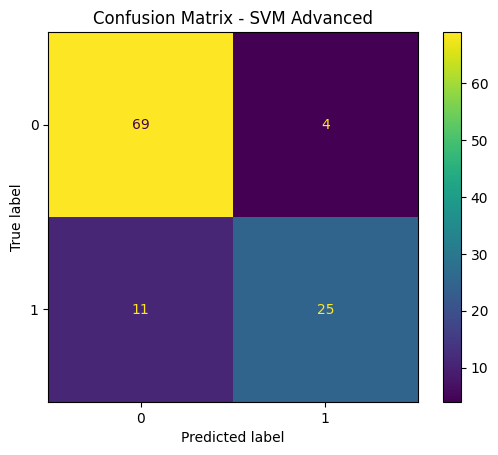

In [119]:
models = {
    "LR Basic": (yb_test, yb_pred_lr),
    "RF Basic": (yb_test, yb_pred_rf),
    "SVM Basic": (yb_test, yb_pred_svm),
    "LR Advanced": (ya_test, ya_pred_lr),
    "RF Advanced": (ya_test, ya_pred_rf),
    "SVM Advanced": (ya_test, ya_pred_svm),
}

for name, (y_true, y_pred) in models.items():
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

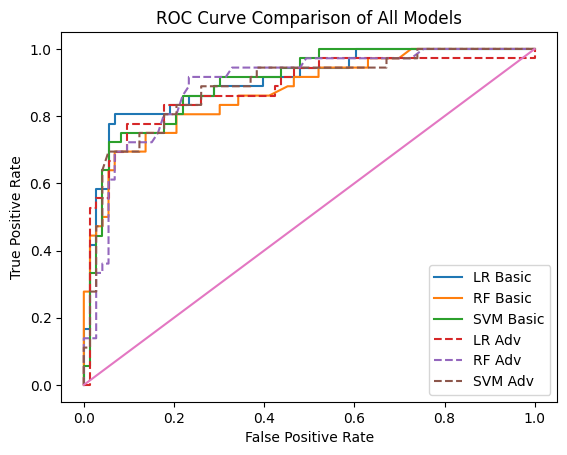

In [120]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure()

# Basic Models
fpr, tpr, _ = roc_curve(yb_test, yb_prob_lr)
plt.plot(fpr, tpr, label="LR Basic")

fpr, tpr, _ = roc_curve(yb_test, yb_prob_rf)
plt.plot(fpr, tpr, label="RF Basic")

fpr, tpr, _ = roc_curve(yb_test, yb_prob_svm)
plt.plot(fpr, tpr, label="SVM Basic")

# Advanced Models
fpr, tpr, _ = roc_curve(ya_test, ya_prob_lr)
plt.plot(fpr, tpr, linestyle="--", label="LR Adv")

fpr, tpr, _ = roc_curve(ya_test, ya_prob_rf)
plt.plot(fpr, tpr, linestyle="--", label="RF Adv")

fpr, tpr, _ = roc_curve(ya_test, ya_prob_svm)
plt.plot(fpr, tpr, linestyle="--", label="SVM Adv")

# Random line
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of All Models")
plt.legend()
plt.show()

In [121]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

model_basic.save("saved_models/basic_ann_model.h5")

joblib.dump(
    scaler_basic,
    "saved_models/basic_ann_scaler.pkl"
)

joblib.dump(
    Xb_train.columns.tolist(),
    "saved_models/basic_ann_features.pkl"
)

print(" Basic ANN model saved successfully!")

joblib.dump(
    rf_adv,
    "saved_models/advanced_rf_model.pkl"
)

joblib.dump(
    Xa_train.columns.tolist(),
    "saved_models/advanced_rf_features.pkl"
)

print(" Advanced RF model saved successfully!")

 Basic ANN model saved successfully!
 Advanced RF model saved successfully!


In [122]:
import shutil
from google.colab import files

shutil.make_archive(
    "saved_models_backup",
    'zip',
    "saved_models"
)

print(" ZIP file created successfully!")
files.download("saved_models_backup.zip")

 ZIP file created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>